In [1]:
total_rooms = 118
low_fare = 159
high_fare = 225
demand_high_fare = 27.3

import numpy as np
from scipy.stats import poisson

import matplotlib.pyplot as plt 
 

In [2]:
# Revenue function
def expected_revenue(protected_high_fare_rooms):
    low_fare_rooms = total_rooms - protected_high_fare_rooms
    revenue = 0
    for d in range(
        total_rooms + 1
    ):  # Potential high fare demand scenarios
        prob = poisson.pmf(d, demand_high_fare)
        if d <= protected_high_fare_rooms:
            # All high fare demand can be accommodated
            revenue += prob * (
                d * high_fare + low_fare_rooms * low_fare
            )
        else:
            # Only protect_high_fare_rooms can be accommodated, rest get low fare
            revenue += prob * (
                protected_high_fare_rooms * high_fare
                + (total_rooms - protected_high_fare_rooms)
                * low_fare
            )
    return revenue


# Optimization
protected_high_fare_rooms_range = range(total_rooms + 1)
revenues = [expected_revenue(ph) for ph in protected_high_fare_rooms_range]

optimal_protected_high_fare_rooms = np.argmax(revenues)
max_revenue = revenues[optimal_protected_high_fare_rooms]

In [3]:
int(optimal_protected_high_fare_rooms)

24

In [4]:
float(max_revenue)

20166.884644620914

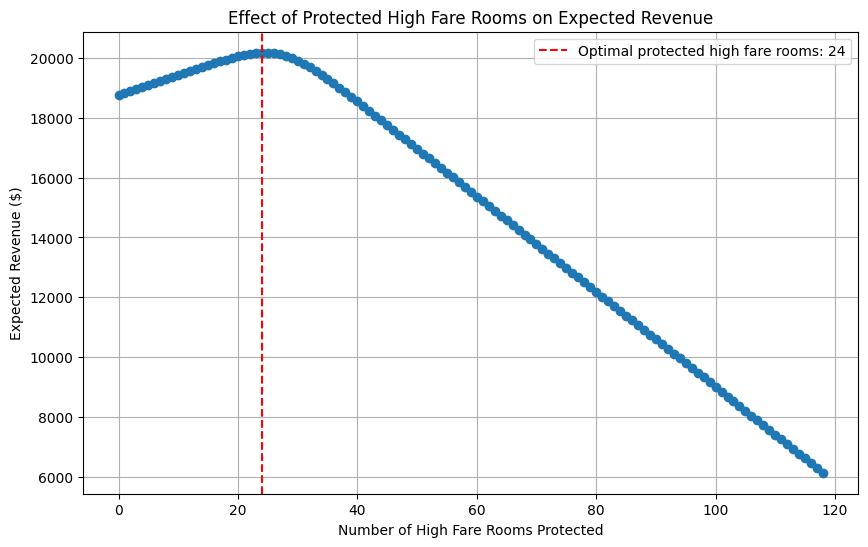

In [5]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(protected_high_fare_rooms_range, revenues, marker='o', linestyle='-')
plt.axvline(optimal_protected_high_fare_rooms, color='r', linestyle='--', label=f'Optimal protected high fare rooms: {optimal_protected_high_fare_rooms}')
plt.xlabel('Number of High Fare Rooms Protected')
plt.ylabel('Expected Revenue ($)')
plt.title('Effect of Protected High Fare Rooms on Expected Revenue')
plt.legend()
plt.grid(True)
plt.show()